In [2]:
%reset -f 
%matplotlib inline
import numpy as np
from matplotlib.animation import FuncAnimation
import os, sys, importlib, json, itertools
from datetime import datetime
from IPython.display import HTML, display
import matplotlib.image as mpimg
import math

# Import the aif module
pwd = os.path.abspath('') + "/"
sys.path.insert(1, pwd + '/aif_catkin_ws/aif_gazebo/scripts/simulation_methods')
#import aif_functions_attention_gpt_with_ambiguity as aif
import aif_functions_attention_gpt_2 as aif 
# import aif_catkin_ws.aif_gazebo.scripts.aif_functions_isobeliefs_adaptable as aif # Interchangeable with aif_functions_isobeliefs and aif_functions_isobeliefs_mcts
importlib.reload(aif)

import os
print(os.cpu_count())

8


In [10]:
# Re-define the environment and simulation parameters here
interactive = True  # Set to True to display the animation in the notebook
fast_plot = True  # Set to True to use the fast plotter (no icons)
use_ep = True  # Set to True to use EP, False to use the standard algorithm
convergence_type = 'exclusive'  # Set to 'converge' to check for convergence, 'exclusive' to check for separate goals
args = {}
# draft_results = []

random_seed = 7 #39 is good too! 2 goals, 3 agents (actually 39 is perfect)
#2 
#35 is good too! 2 goals, 3 agents --- i use this for the paper converging*
#5 is good too! 3 goals, 3 agents --- i use this for the paper exclusive*

np.random.seed(random_seed)  # Set random seed
# Set random goals
env_size = 30 # Environment size
iterations_per_episode = 100  # Number of iterations per episode
num_goals = 7 # Number of goals
num_agents = 7  # Number of agents
list_types = ['A','B']

goals = np.array([[25,25],
                  [10,15],
                  [10,1],
                  [20,15],
                  [2,22],
                  [9,17],
                  [3,2],
                  ], dtype=float)

agent_positions = np.array([[4, 8, 0],
                            [1, 9, np.pi],
                            [16, 18, 0],
                            [8, 21, np.pi/2],
                            [11, 3, np.pi/0.667],
                            [15, 14, 0],
                            [18, 10, np.pi]
                            ], dtype=float)
#goals = np.random.uniform(1,env_size-1,size=(num_goals, 2))  # Goal positions
# goals = np.array([[-2,5], [5,5]], dtype=float)
# goals = np.array([[0,0],[env_size-5,0]], dtype=float)  # Goal positions
# goals = np.array([[0.15, 0.1], [0.5,0.55]])

#agent_positions = np.hstack((np.random.uniform(0,env_size,size=(num_agents, 2)),np.zeros((num_agents,1))))  # Initial agent positions
# agent_positions = np.array([[0,0,0],[5,0,0]], dtype=float)
# agent_positions = np.array([[4.45,4.45,-3*np.pi/4],[3.45,3.5,-3*np.pi/4]], dtype=float)
agent_types = np.array(['A', 'A', 'A', 'A', 'A', 'A', 'B'])  # Agent types
number_of_heading_options = 8; number_of_velocity_options = 4
args = dict({
    'goals': goals, # Goal positions
    'home_base': np.array([0,0]), # Home base position
    'agent_types': agent_types,#np.repeat('A',num_agents),#np.random.choice(list_types,num_agents),#['A','B','B'],#np.random.choice(list_types,num_agents), # Agent types
    'agent_positions': agent_positions, # Initial agent positions
    'velocity_options': np.linspace(0.0,1,number_of_velocity_options,endpoint=True), # Velocity options
    'num_heading_options': number_of_heading_options, # Number of heading options
    'heading_options': np.linspace(-np.pi/4,np.pi/4,number_of_heading_options,endpoint=True),
    'observation_error_std': 0.2, # Observation error standard deviation
    'num_actions': number_of_heading_options*number_of_velocity_options, # Number of actions
    'env_size': env_size, # Environment size
    'max_distance_measure': env_size + 1,
    'max_heading_measure': np.pi, # Maximum heading measure
    'prior': np.ones(goals.shape[0]) / goals.shape[0], # Prior belief
    'use_ep': use_ep, # Use epistemic planning (2nd order reasoning)
    'greedy': False, # Use greedy action selection
    'horizon': 1, # Horizon for free energy checking
    'mcts_iterations': 100, # Number of MCTS iterations
    'use_mcts': False,
    'use_rhc': False,
    'use_threading': False, #TODO: Implement threading
    'convergence_type': convergence_type, # Convergence type
    'dt': 0.5, # Time step
    'query': 'all', #Options are all, none, closest, openai, and meta
    'num_goal_configs': math.factorial(num_goals), #The number of goals configurations to consider. Lower = faster runtime
    'second_order_robots': []
})

# Check convergence for different types of conergence criterion
if args['convergence_type'] == 'exclusive':
    tuple_elements = [i for i in range(agent_positions.shape[0])]
    configurations = list(itertools.permutations(tuple_elements))
    args['reward_configs'] = configurations # Reward configurations if different goals
else:
    args['reward_configs'] = [tuple(np.repeat(i, num_agents)) for i in range(num_goals)]

# Run the simulation
results = aif.run_simulation(args, iterations_per_episode)
#print("Final Prior: ", results['priors'])
#print("Agent Types: ", args['agent_types'])





agent  0 best decision is  (1.0, -0.7853981633974483)
agent  1 best decision is  (1.0, -0.7853981633974483)
agent  2 best decision is  (1.0, 0.7853981633974483)
agent  3 best decision is  (1.0, 0.7853981633974483)
agent  4 best decision is  (1.0, -0.3365992128846207)
agent  5 best decision is  (0.0, -0.7853981633974483)
agent  6 best decision is  (0.0, -0.7853981633974483)
Decisions for iteration  0  is  [(1.0, -0.7853981633974483), (1.0, -0.7853981633974483), (1.0, 0.7853981633974483), (1.0, 0.7853981633974483), (1.0, -0.3365992128846207), (0.0, -0.7853981633974483), (0.0, -0.7853981633974483)]
Iteration 1: Agents have selected goals [6, 6, 3, 5, 2, 1, 3]. Execution Time: 32.159661293029785s
 agent  0 best decision is  (1.0, -0.7853981633974483)
agent  1 best decision is  (1.0, -0.5609986881410345)
agent  2 best decision is  (1.0, -0.1121997376282069)
agent  3 best decision is  (1.0, 0.3365992128846207)
agent  4 best decision is  (1.0, -0.1121997376282069)
agent  5 best decision is  (

Image saved as:  c:\Users\jonat\OneDrive\Documents\Active_Inference\active_inference_playground\aif_multi_robot/videos/Converged_numRobots7_numGoals7_seed7_EPTrue_goalTypeexclusive_envSize30.mp4


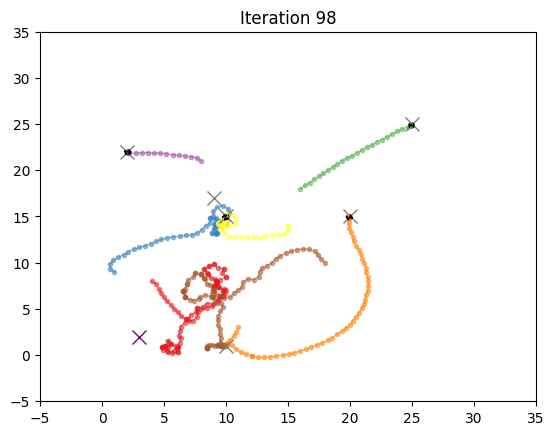

In [9]:
# Create animation
if not fast_plot:
    completed_task_img = mpimg.imread('figures/meeting_icon_selected.png')
    not_completed_task_img = mpimg.imread('figures/meeting_icon_not_selected.png')
    plt_sim = aif.PlotSim(num_agents, goals, args['agent_types'], completed_task_img, not_completed_task_img, env_size, padding=5, scale = 0.3)
else:
    plt_sim = aif.PlotSim_fast(num_agents, goals, args['agent_types'],env_size, padding=5, scale = 0.1)
ani = FuncAnimation(plt_sim.fig, plt_sim.update, frames=range(results['iteration']), init_func=plt_sim.init, fargs = (results['plot_args'],), blit=True, repeat=True)

# Save the animation as a video
current_time = datetime.now().strftime("%Y%m%d-%H%M%S")
config_file = ["numRobots", num_agents, "_numGoals", num_goals, "_seed", random_seed, "_EP", args['use_ep'], "_goalType", convergence_type, "_envSize", env_size]
config_file = ''.join([str(elem) for elem in config_file])
if results['converged'] == None and not interactive:
    filepath = pwd + "videos/NO_convergence_" + config_file + ".mp4"
    ani.save(filepath, writer='ffmpeg', fps=3, dpi=200)
    # Save location of the final image
    print("Image saved as: ", filepath)
elif not interactive:
    filepath = pwd + "videos/Converged_" + config_file + ".mp4"
    ani.save(filepath, writer='ffmpeg', fps=3, dpi=200)
    # Save location of the final image
    print("Image saved as: ", filepath)
else:
    display(HTML(ani.to_jshtml())) # Use an interactive backend for animation
    filepath = pwd + "videos/Converged_" + config_file + ".mp4"
    ani.save(filepath, writer='ffmpeg', fps=3, dpi=200)
    # Save location of the final image
    print("Image saved as: ", filepath)

Next steps: 

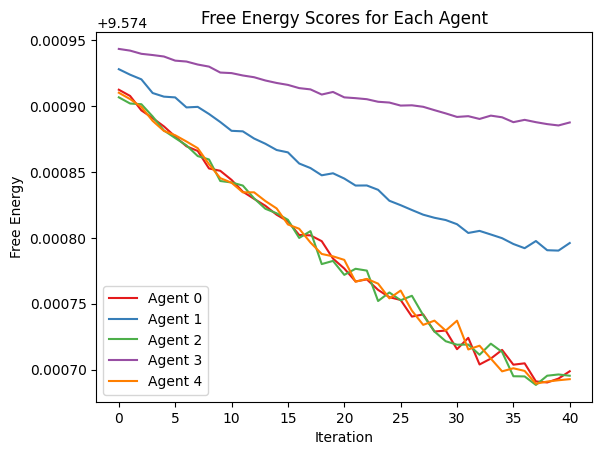

[(0, 1, 2, 3, 4), (0, 1, 2, 4, 3), (0, 1, 3, 2, 4), (0, 1, 3, 4, 2), (0, 1, 4, 2, 3), (0, 1, 4, 3, 2), (0, 2, 1, 3, 4), (0, 2, 1, 4, 3), (0, 2, 3, 1, 4), (0, 2, 3, 4, 1), (0, 2, 4, 1, 3), (0, 2, 4, 3, 1), (0, 3, 1, 2, 4), (0, 3, 1, 4, 2), (0, 3, 2, 1, 4), (0, 3, 2, 4, 1), (0, 3, 4, 1, 2), (0, 3, 4, 2, 1), (0, 4, 1, 2, 3), (0, 4, 1, 3, 2), (0, 4, 2, 1, 3), (0, 4, 2, 3, 1), (0, 4, 3, 1, 2), (0, 4, 3, 2, 1), (1, 0, 2, 3, 4), (1, 0, 2, 4, 3), (1, 0, 3, 2, 4), (1, 0, 3, 4, 2), (1, 0, 4, 2, 3), (1, 0, 4, 3, 2), (1, 2, 0, 3, 4), (1, 2, 0, 4, 3), (1, 2, 3, 0, 4), (1, 2, 3, 4, 0), (1, 2, 4, 0, 3), (1, 2, 4, 3, 0), (1, 3, 0, 2, 4), (1, 3, 0, 4, 2), (1, 3, 2, 0, 4), (1, 3, 2, 4, 0), (1, 3, 4, 0, 2), (1, 3, 4, 2, 0), (1, 4, 0, 2, 3), (1, 4, 0, 3, 2), (1, 4, 2, 0, 3), (1, 4, 2, 3, 0), (1, 4, 3, 0, 2), (1, 4, 3, 2, 0), (2, 0, 1, 3, 4), (2, 0, 1, 4, 3), (2, 0, 3, 1, 4), (2, 0, 3, 4, 1), (2, 0, 4, 1, 3), (2, 0, 4, 3, 1), (2, 1, 0, 3, 4), (2, 1, 0, 4, 3), (2, 1, 3, 0, 4), (2, 1, 3, 4, 0), (2, 1, 4, 0, 

In [10]:
avg_nrg_over_time = results['energy_scores']
num_frames = results['iteration']
energy_results, ending_energy = aif.parse_free_energy_scores(avg_nrg_over_time, num_frames)
aif.plot_energy(energy_results, num_agents)
print(args['reward_configs'])

In [ ]:
# Calculate distance to final goals
final_distances = np.zeros((num_agents, goals.shape[0]))
for i in range(num_agents):
    for j in range(goals.shape[0]):
        final_distances[i,j] = np.linalg.norm(results['positions'][i,:2] - goals[j,:])
print("Final distances: ", final_distances)


Final distances:  [[0.04272534 4.99155181]
 [0.04607108 5.04569454]]


In [56]:
# Scratch code for testing

goals = np.array([[0,0],[0.,10.]])
my_pose = np.array([14.12709979, 12.76192634,  0.])
other_pose = np.array([6.30305407,  7.28140647,  0.])
saliences = np.zeros(goals.shape[0])
goal_azimuths = np.arctan2(goals[:, 1] - my_pose[1], goals[:, 0] - my_pose[0])
observed_azimuth = np.arctan2(other_pose[1] - my_pose[1], other_pose[0] - my_pose[0])
relative_azimuths = np.abs((goal_azimuths - observed_azimuth + np.pi) % (2 * np.pi) - np.pi)
azimuth_salience = 1./8 * np.exp(- relative_azimuths / np.pi)  # normalize and invert to make smaller angles more salient
saliences += azimuth_salience
# Compute if observed robot is heading towards the goal
# heading_to_goal = (np.arctan2(goals[:, 1] - observation['position'][1], goals[:, 0] - observation['position'][0]) - observation['heading'] + np.pi) % (2 * np.pi) - np.pi
# heading_salience = 1./8 * np.exp(- np.abs(heading_to_goal) / np.pi)
# saliences += heading_salience


print("Goal Azimuth: ", goal_azimuths)
print("Relative Azimuth: ", azimuth_salience)
print("Observed Azimuth: ", observed_azimuth)
print("Salience: ", saliences)
# print("Heading Salience: ", heading_salience)
print(np.exp(0.8/np.pi))

Goal Azimuth:  [-2.40692159 -2.9485224 ]
Relative Azimuth:  [0.1201765  0.10942825]
Observed Azimuth:  -2.5305504167886905
Salience:  [0.1201765  0.10942825]
1.2900073408606396


In [ ]:
poses = np.array([[0,0],[0,0]])+0.5
print(poses)
distance = sum(poses[i][dim] - poses[j][dim] for i in range(2) for j in range(2) if i != j for dim in range(2))
1e4 / (1+np.exp(100*(distance - 1.5)))

[[0.5 0.5]
 [0.5 0.5]]


10000.0